In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_benchmark_results(labels, scores, times, std_devs=None, title="Comparaison des Performances"):
    """
    Génère un double bar plot comparant les scores (axe gauche) et le temps (axe droit).
    
    Args:
        labels (list): Liste des noms des configurations.
        scores (list): Liste des scores moyens.
        times (list): Liste des temps d'exécution moyens.
        std_devs (list, optional): Liste des écarts-types pour les barres d'erreur.
        title (str): Titre du graphique.
    """
    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Axe 1 : Score Moyen (Bleu)
    ax1.bar(x - width/2, scores, width, yerr=std_devs, 
            label='Score Moyen', color='skyblue', capsize=5, alpha=0.8)
    ax1.set_xlabel('Configurations', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Score Moyen', color='blue', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # Ajustement dynamique de l'échelle du score
    ax1.set_ylim(0, max(scores) + (max(std_devs) if std_devs else 0) * 1.2 + 5000)

    # Axe 2 : Temps Moyen (Rouge)
    ax2 = ax1.twinx()
    ax2.bar(x + width/2, times, width, 
            label='Temps Moyen (s)', color='salmon', alpha=0.8)
    ax2.set_ylabel('Temps Moyen par Partie (sec)', color='red', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Ajustement dynamique de l'échelle du temps
    ax2.set_ylim(0, max(times) * 1.2)

    # Esthétique
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # Légende combinée
    lines, labels_leg = ax1.get_legend_handles_labels()
    lines2, labels_leg2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels_leg + labels_leg2, loc='upper right')

    fig.tight_layout()
    plt.show()

# Flat Monte Carlo Search

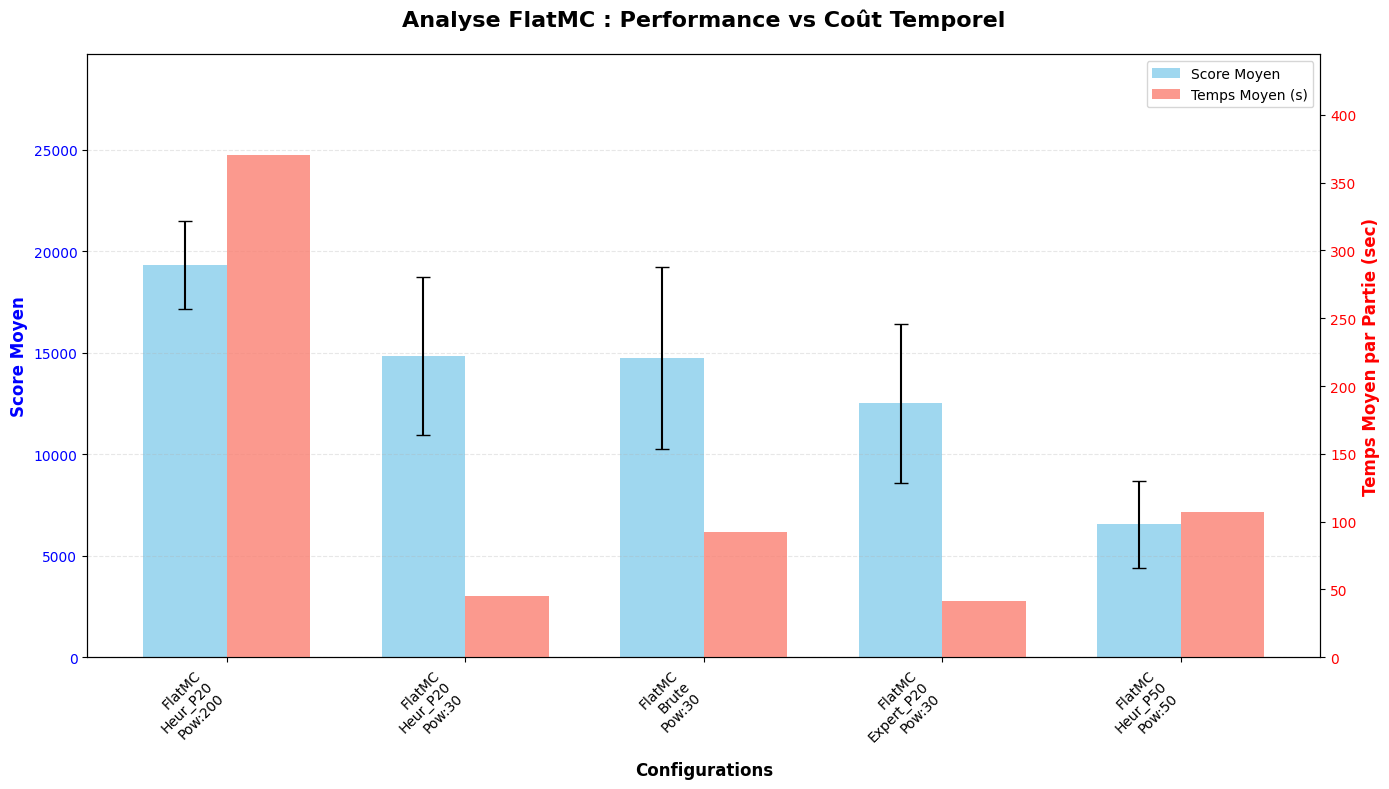

In [ ]:
# 1. Données extraites de vos fichiers sources
configs_flatmc = [
    "FlatMC\nHeur_P20\nPow:100", # 
    "FlatMC\nHeur_P20\nPow:200", # 
    "FlatMC\nHeur_P20\nPow:30",  # 
    "FlatMC\nBrute\nPow:30",     # [cite: 5]
    "FlatMC\nExpert_P20\nPow:30",# 
    "FlatMC\nHeur_P50\nPow:50"   # 
]

scores = [ 19325.20, 14852.80, 14746.40, 12502.00, 6546.40] # 
ecarts = [ 2157.31, 3892.50, 4469.03, 3916.71, 2148.20]      # 
temps  = [ 370.47, 45.55, 92.56, 41.30, 106.91]              # 




# Appel de la fonction
plot_benchmark_results(
    labels=configs_flatmc, 
    scores=scores, 
    times=temps, 
    std_devs=ecarts, 
    title="Analyse FlatMC : Performance vs Coût Temporel"
)

# A retenir : 
# Score : 19991.20
# Ecart : 7133.90
# Temps : 188.49

# MCTS avec UCB

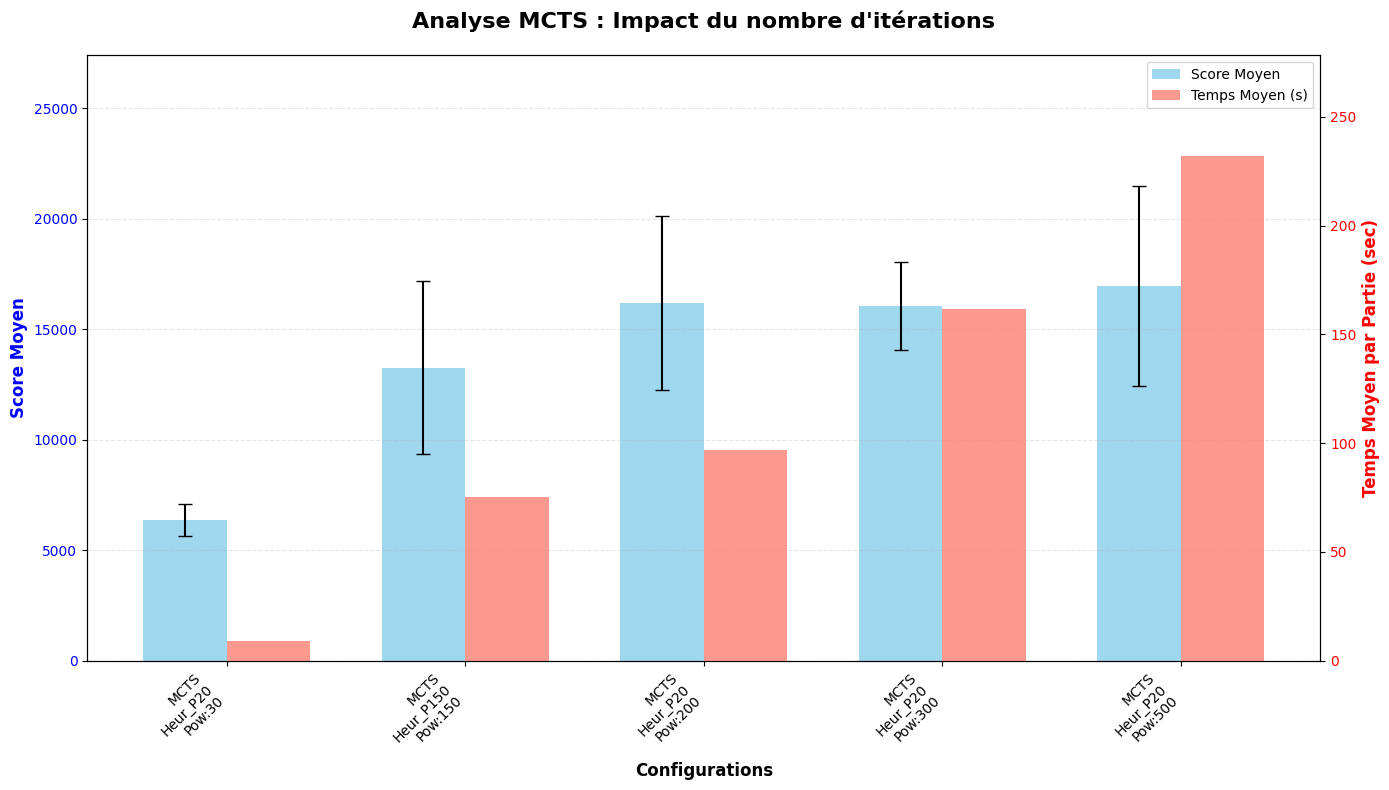

In [ ]:
# 1. Données extraites de vos fichiers sources MCTS (ordonnées par itérations)
configs_mcts = [
    "MCTS\nHeur_P20\nPow:30",  # 
    "MCTS\nHeur_P150\nPow:150",# 
    "MCTS\nHeur_P20\nPow:200", # 
    "MCTS\nHeur_P20\nPow:300", # 
    "MCTS\nHeur_P20\nPow:500"  # 
]

# Scores Moyens 
scores_mcts = [6366.00, 13252.00, 16174.40, 16036.40, 16949.60]

# Écarts-types 
ecarts_mcts = [726.90, 3920.60, 3924.44, 1987.60, 4531.51]

# Temps Moyens par partie en secondes 
temps_mcts  = [8.93, 75.13, 96.79, 161.60, 231.88]

# 2. Appel de la fonction de visualisation
plot_benchmark_results(
    labels=configs_mcts, 
    scores=scores_mcts, 
    times=temps_mcts, 
    std_devs=ecarts_mcts, 
    title="Analyse MCTS : Impact du nombre d'itérations"
)

# NMCS (Nested Monte Carlo Search)

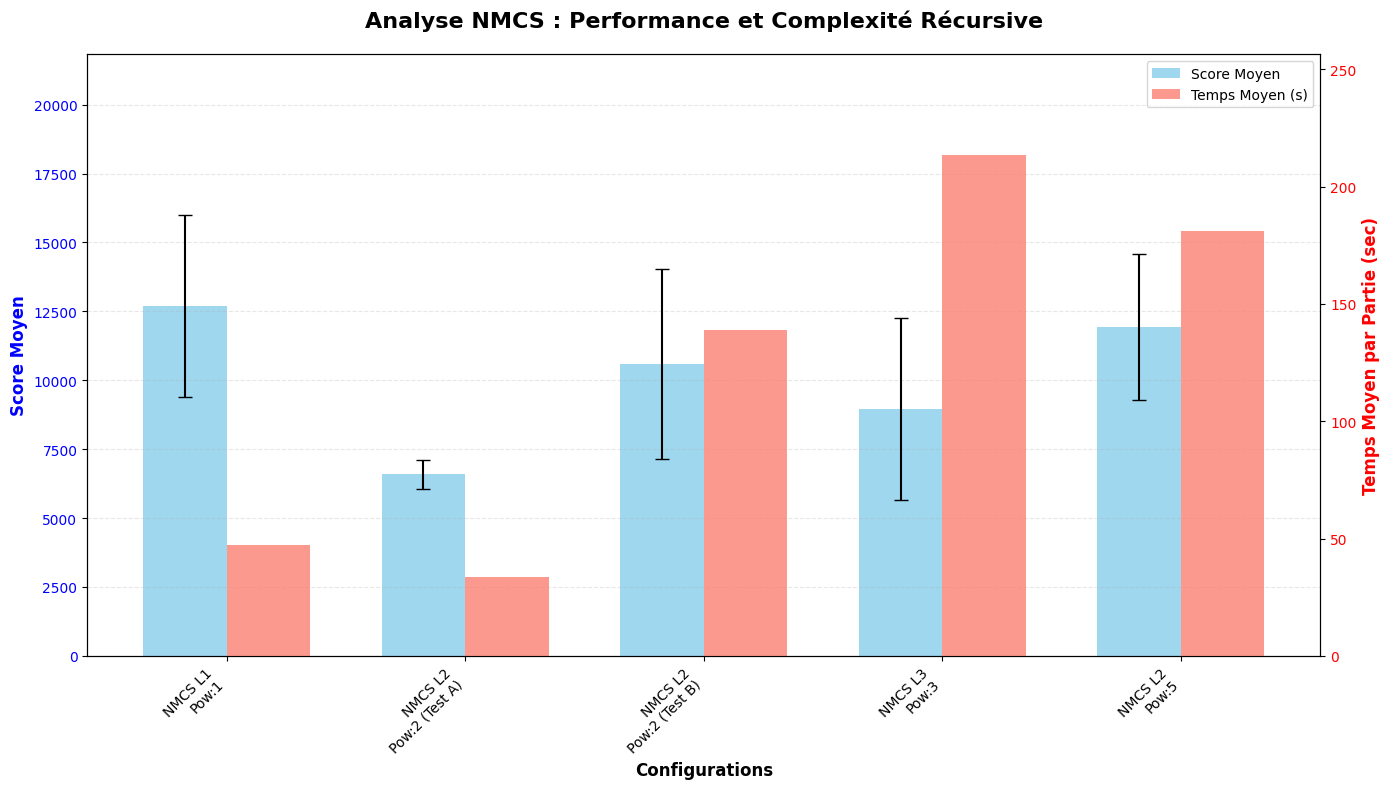

In [11]:
# 1. Données extraites de vos fichiers sources NMCS et MCTS 500
configs_nmcs = [
    "NMCS L1\nPow:1",          # Source 11
    "NMCS L2\nPow:2 (Test A)", # Source 12
    "NMCS L2\nPow:2 (Test B)", # Source 13
    "NMCS L3\nPow:3",          # Source 14
    "NMCS L2\nPow:5",          # Source 15
]

# Scores Moyens
scores_nmcs = [12703.60, 6582.00, 10583.20, 8952.00, 11932.00]

# Écarts-types
ecarts_nmcs = [3300.13, 519.37, 3438.04, 3291.00, 2643.06]

# Temps Moyens par partie en secondes
temps_nmcs  = [47.20, 33.67, 139.07, 213.70, 181.14]

# 2. Appel de la fonction de visualisation
plot_benchmark_results(
    labels=configs_nmcs, 
    scores=scores_nmcs, 
    times=temps_nmcs, 
    std_devs=ecarts_nmcs, 
    title="Analyse NMCS : Performance et Complexité Récursive"
)

# Conclusion

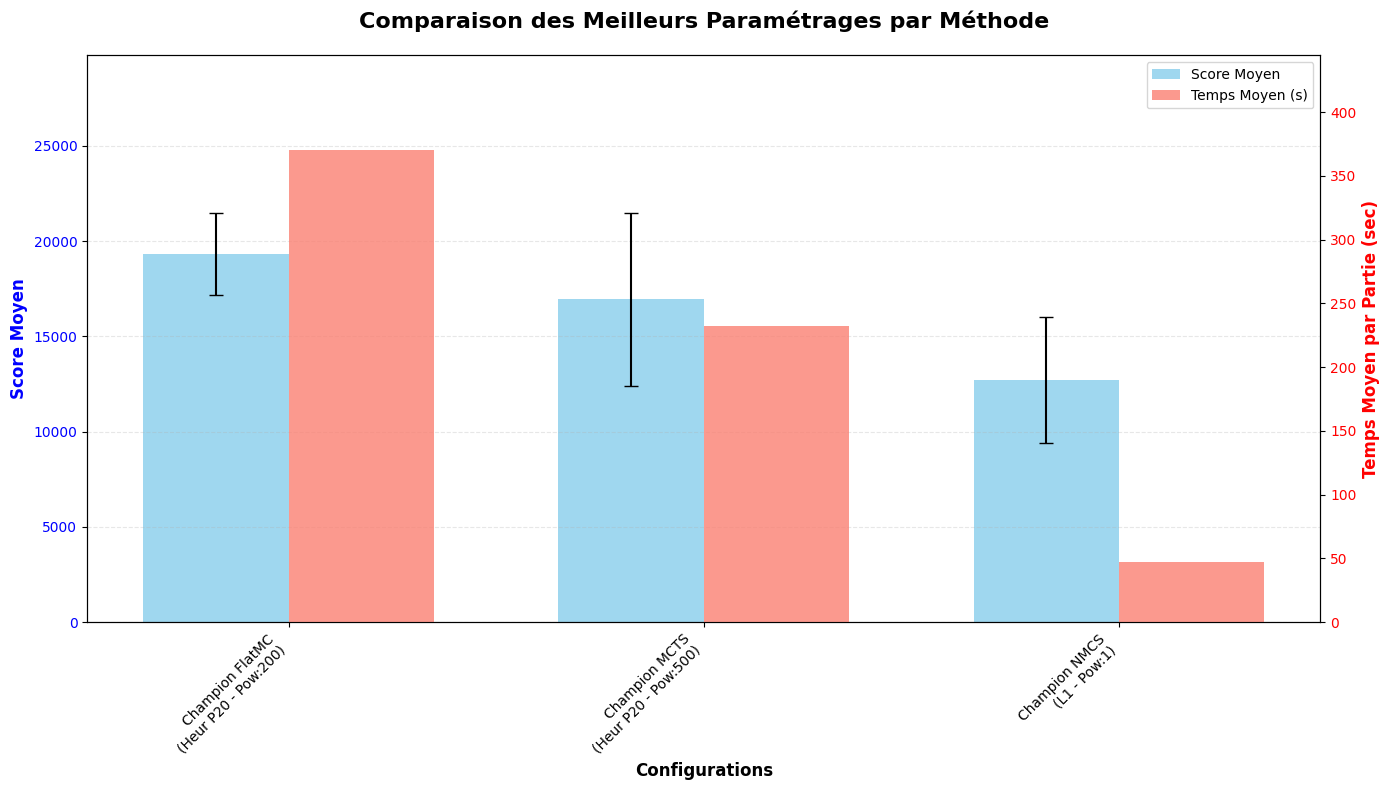

In [14]:
# 1. Sélection des meilleurs résultats de chaque catégorie
labels_champions = [
    "Champion FlatMC\n(Heur P20 - Pow:200)", 
    "Champion MCTS\n(Heur P20 - Pow:500)", 
    "Champion NMCS\n(L1 - Pow:1)"
]

# Scores Moyens des champions
scores_champions = [19325.20, 16949.60, 12703.60]

# Écarts-types associés
ecarts_champions = [2157.31, 4531.51, 3300.13]

# Temps Moyens par partie associés
temps_champions  = [370.47, 231.88, 47.20]

# 2. Appel de la fonction de visualisation globale
plot_benchmark_results(
    labels=labels_champions, 
    scores=scores_champions, 
    times=temps_champions, 
    std_devs=ecarts_champions, 
    title="Comparaison des Meilleurs Paramétrages par Méthode"
)